# Research-Grade Multilingual Handwritten OCR Pipeline

This notebook is organized as a debug-first research pipeline for handwritten OCR.

Image Input → Preprocessing → Line Segmentation → Word Segmentation → Word-level Bounding Boxes → Language Detection (per word) → Language-specific OCR → Post-processing

Design priorities:
- Every stage stores intermediate artifacts for inspection.
- Every transformation can be visualized independently.
- Language handling is modular and replaceable.
- Failure cases remain visible instead of being hidden inside a single black-box call.

Use this notebook in top-to-bottom order, or call `run_full_pipeline(...)` directly once the configuration is set.

## Configuration Section

All tunable parameters live here so the pipeline can be debugged and retuned without touching the stage logic.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
import math
import re

import cv2
import editdistance
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont

try:
    import pytesseract
except Exception:
    pytesseract = None

try:
    from jiwer import wer as jiwer_wer
except Exception:
    jiwer_wer = None

DEBUG = True
SEED = 42
IMAGE_PATH: Optional[str] = None
OUTPUT_DPI = 120
FIGSIZE_SINGLE = (14, 8)
FIGSIZE_PAIR = (16, 8)

CONFIG: Dict[str, Any] = {
    "debug": DEBUG,
    "seed": SEED,
    "image_path": IMAGE_PATH,
    "output_dpi": OUTPUT_DPI,
    "preprocessing": {
        "clahe_clip_limit": 2.0,
        "clahe_tile_grid_size": (8, 8),
        "gaussian_blur_kernel": (3, 3),
        "denoise_strength": 5,
        "threshold_block_size": 31,
        "threshold_c": 11,
        "morph_kernel": (2, 2),
        "deskew_enabled": True,
    },
    "line_segmentation": {
        "projection_threshold_ratio": 0.06,
        "min_line_height": 10,
        "line_padding": 4,
    },
    "word_segmentation": {
        "min_contour_area": 40,
        "min_word_width": 8,
        "min_word_height": 10,
        "word_gap_factor": 1.35,
        "min_gap_threshold": 12,
        "max_gap_threshold": 80,
        "word_padding": 3,
    },
    "ocr": {
        "english": "eng",
        "marathi": "mar+hin",
        "tamil": "tam",
        "psm": 7,
        "oem": 1,
    },
    "language_map": {
        "Latin": ("English", 0.95),
        "Devanagari": ("Marathi", 0.95),
        "Tamil": ("Tamil", 0.95),
    },
}

np.random.seed(SEED)

@dataclass
class WordResult:
    line_index: int
    word_index: int
    bbox: Tuple[int, int, int, int]
    language: str
    language_confidence: float
    text: str
    ocr_confidence: float
    crop: Optional[np.ndarray] = field(default=None, repr=False)
    language_source: str = "unknown"

    def as_dict(self) -> Dict[str, Any]:
        return {
            "line_index": self.line_index,
            "word_index": self.word_index,
            "bbox": self.bbox,
            "language": self.language,
            "language_confidence": self.language_confidence,
            "text": self.text,
            "ocr_confidence": self.ocr_confidence,
            "language_source": self.language_source,
        }


@dataclass
class PipelineResult:
    original_image: np.ndarray
    debug: Dict[str, Any]
    lines: List[Dict[str, Any]]
    words: List[WordResult]
    reconstructed_text: str

    def to_dict(self) -> Dict[str, Any]:
        return {
            "original_image": self.original_image,
            "debug": self.debug,
            "lines": self.lines,
            "words": [word.as_dict() for word in self.words],
            "reconstructed_text": self.reconstructed_text,
        }


print("[OK] Imports and config loaded")
print(f"[OK] DEBUG = {DEBUG}")
print(f"[OK] pytesseract available = {pytesseract is not None}")


[OK] Imports and config loaded
[OK] DEBUG = True
[OK] pytesseract available = True


## Visualization Helpers

Functions to inspect intermediate results at every stage. These are called automatically when DEBUG=True.

In [2]:
def show_image(image: np.ndarray, title: str = "Image", figsize: Tuple[int, int] = FIGSIZE_SINGLE, dpi: int = OUTPUT_DPI) -> None:
    """Display an image with matplotlib."""
    plt.figure(figsize=figsize, dpi=dpi)
    if len(image.shape) == 2:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_bounding_boxes(image: np.ndarray, bboxes: List[Tuple[int, int, int, int]], title: str = "Bounding Boxes", colors: Optional[List[str]] = None, figsize: Tuple[int, int] = FIGSIZE_SINGLE, dpi: int = OUTPUT_DPI) -> None:
    """Display image with bounding boxes drawn."""
    if colors is None:
        colors = ['red'] * len(bboxes)
    
    plt.figure(figsize=figsize, dpi=dpi)
    if len(image.shape) == 2:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    
    for bbox, color in zip(bboxes, colors):
        x1, y1, x2, y2 = bbox
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2))
    
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_side_by_side(left: np.ndarray, right: np.ndarray, left_title: str = "Left", right_title: str = "Right", figsize: Tuple[int, int] = FIGSIZE_PAIR, dpi: int = OUTPUT_DPI) -> None:
    """Display two images side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
    
    if len(left.shape) == 2:
        ax1.imshow(left, cmap='gray')
    else:
        ax1.imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB))
    ax1.set_title(left_title)
    ax1.axis('off')
    
    if len(right.shape) == 2:
        ax2.imshow(right, cmap='gray')
    else:
        ax2.imshow(cv2.cvtColor(right, cv2.COLOR_BGR2RGB))
    ax2.set_title(right_title)
    ax2.axis('off')
    
    plt.show()


def show_debug_panel(debug: Dict[str, Any], figsize: Tuple[int, int] = FIGSIZE_SINGLE, dpi: int = OUTPUT_DPI) -> None:
    """Display debug information in a structured way."""
    print("=== DEBUG PANEL ===")
    for key, value in debug.items():
        if isinstance(value, np.ndarray):
            print(f"{key}: shape={value.shape}, dtype={value.dtype}")
        elif isinstance(value, (list, tuple)):
            print(f"{key}: {len(value)} items")
        else:
            print(f"{key}: {value}")
    print("===================")


def show_word_results(words: List[WordResult], figsize: Tuple[int, int] = FIGSIZE_SINGLE, dpi: int = OUTPUT_DPI) -> None:
    """Display word-level results in a table."""
    import pandas as pd
    df = pd.DataFrame([word.as_dict() for word in words])
    print("Word Results:")
    print(df.to_string(index=False))


print("[OK] Visualization helpers loaded")

[OK] Visualization helpers loaded


## Preprocessing Stage

Image enhancement and noise reduction. This stage prepares the image for segmentation.

In [3]:
def preprocess_image(image: np.ndarray, config: Dict[str, Any]) -> Tuple[np.ndarray, Dict[str, Any]]:
    """Apply preprocessing pipeline to enhance image quality."""
    debug = {}
    
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    debug['gray'] = gray
    
    # CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(
        clipLimit=config['clahe_clip_limit'],
        tileGridSize=config['clahe_tile_grid_size']
    )
    enhanced = clahe.apply(gray)
    debug['enhanced'] = enhanced
    
    # Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(enhanced, config['gaussian_blur_kernel'], 0)
    debug['blurred'] = blurred
    
    # Denoising
    denoised = cv2.fastNlMeansDenoising(blurred, h=config['denoise_strength'])
    debug['denoised'] = denoised
    
    # Adaptive thresholding
    thresh = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV,
        config['threshold_block_size'], config['threshold_c']
    )
    debug['thresh'] = thresh
    
    # Morphological operations to clean up
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, config['morph_kernel'])
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    debug['cleaned'] = cleaned
    
    # Deskew if enabled
    if config['deskew_enabled']:
        angle = _calculate_skew_angle(cleaned)
        if abs(angle) > 0.5:
            cleaned = _rotate_image(cleaned, angle)
            debug['deskewed'] = cleaned
            debug['deskew_angle'] = angle
        else:
            debug['deskew_angle'] = 0.0
    
    return cleaned, debug


def _calculate_skew_angle(image: np.ndarray) -> float:
    """Calculate the skew angle of the image using Hough transform."""
    edges = cv2.Canny(image, 50, 150, apertureSize=3)
    lines = cv2.HoughLines(edges, 1, np.pi/180, 100)
    
    if lines is None:
        return 0.0
    
    angles = []
    for line in lines:
        rho, theta = line[0]
        angle = theta * 180 / np.pi - 90
        if abs(angle) < 45:  # Filter out near-vertical lines
            angles.append(angle)
    
    if not angles:
        return 0.0
    
    # Return median angle
    return np.median(angles)


def _rotate_image(image: np.ndarray, angle: float) -> np.ndarray:
    """Rotate image by given angle."""
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return rotated


print("[OK] Preprocessing functions loaded")

[OK] Preprocessing functions loaded


## Line Segmentation Stage

Split the preprocessed image into individual text lines using horizontal projection.

In [4]:
def segment_lines(image: np.ndarray, config: Dict[str, Any]) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """Segment image into text lines using horizontal projection."""
    debug = {}
    
    # Calculate horizontal projection
    projection = np.sum(image, axis=1, dtype=np.float32)
    projection = projection / np.max(projection) if np.max(projection) > 0 else projection
    debug['projection'] = projection
    
    # Find line boundaries
    height, width = image.shape
    threshold = config['projection_threshold_ratio'] * np.max(projection)
    debug['threshold'] = threshold
    
    line_starts = []
    line_ends = []
    in_line = False
    
    for y in range(height):
        if projection[y] > threshold:
            if not in_line:
                line_starts.append(y)
                in_line = True
        else:
            if in_line:
                line_ends.append(y)
                in_line = False
    
    if in_line:
        line_ends.append(height)
    
    # Filter and pad lines
    lines = []
    for start, end in zip(line_starts, line_ends):
        line_height = end - start
        if line_height >= config['min_line_height']:
            padded_start = max(0, start - config['line_padding'])
            padded_end = min(height, end + config['line_padding'])
            line_crop = image[padded_start:padded_end, :]
            lines.append({
                'bbox': (0, padded_start, width, padded_end),
                'crop': line_crop,
                'line_index': len(lines)
            })
    
    debug['line_count'] = len(lines)
    debug['line_bboxes'] = [line['bbox'] for line in lines]
    
    return lines, debug


print("[OK] Line segmentation functions loaded")

[OK] Line segmentation functions loaded


## Word Segmentation Stage

Split each line into individual words using contour detection and gap analysis.

In [5]:
def segment_words(line_crop: np.ndarray, line_bbox: Tuple[int, int, int, int], line_index: int, config: Dict[str, Any]) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    """Segment a line into individual words."""
    debug = {}
    
    # Find contours
    contours, _ = cv2.findContours(line_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    debug['contours'] = len(contours)
    
    # Filter contours by area and size
    valid_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        x, y, w, h = cv2.boundingRect(contour)
        if (area >= config['min_contour_area'] and 
            w >= config['min_word_width'] and 
            h >= config['min_word_height']):
            valid_contours.append((x, y, w, h))
    
    debug['valid_contours'] = len(valid_contours)
    
    if not valid_contours:
        return [], debug
    
    # Sort contours left to right
    valid_contours.sort(key=lambda c: c[0])
    
    # Merge overlapping or close contours
    merged_contours = _merge_contours(valid_contours, config)
    debug['merged_contours'] = len(merged_contours)
    
    # Create word crops
    words = []
    for i, (x, y, w, h) in enumerate(merged_contours):
        # Add padding
        pad = config['word_padding']
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(line_crop.shape[1], x + w + pad)
        y2 = min(line_crop.shape[0], y + h + pad)
        
        word_crop = line_crop[y1:y2, x1:x2]
        
        # Adjust bbox to global coordinates
        global_x1 = line_bbox[0] + x1
        global_y1 = line_bbox[1] + y1
        global_x2 = line_bbox[0] + x2
        global_y2 = line_bbox[1] + y2
        
        words.append({
            'bbox': (global_x1, global_y1, global_x2, global_y2),
            'crop': word_crop,
            'line_index': line_index,
            'word_index': i
        })
    
    debug['word_count'] = len(words)
    debug['word_bboxes'] = [word['bbox'] for word in words]
    
    return words, debug


def _merge_contours(contours: List[Tuple[int, int, int, int]], config: Dict[str, Any]) -> List[Tuple[int, int, int, int]]:
    """Merge overlapping or close contours into word groups."""
    if not contours:
        return []
    
    merged = [contours[0]]
    
    for x, y, w, h in contours[1:]:
        last_x, last_y, last_w, last_h = merged[-1]
        last_end = last_x + last_w
        
        # Calculate gap
        gap = x - last_end
        
        # Merge if overlapping or gap is small
        if gap <= 0 or gap <= config['min_gap_threshold'] or gap <= config['word_gap_factor'] * max(h, last_h):
            # Merge bounding boxes
            new_x = min(last_x, x)
            new_y = min(last_y, y)
            new_w = max(last_x + last_w, x + w) - new_x
            new_h = max(last_y + last_h, y + h) - new_y
            merged[-1] = (new_x, new_y, new_w, new_h)
        else:
            merged.append((x, y, w, h))
    
    return merged


print("[OK] Word segmentation functions loaded")

[OK] Word segmentation functions loaded


## Language Detection Stage

Detect the script/language of each word crop using OCR with fallback heuristics.

In [6]:
def detect_word_language(word_crop: np.ndarray, config: Dict[str, Any]) -> Tuple[str, float, str]:
    """Detect the language/script of a word crop."""
    if pytesseract is None:
        return "English", 0.5, "fallback"
    
    # Try OCR with different languages to detect script
    results = {}
    
    for lang_code, lang_name in [("eng", "English"), ("mar+hin", "Marathi"), ("tam", "Tamil")]:
        try:
            data = pytesseract.image_to_data(word_crop, lang=lang_code, config='--psm 10', output_type=pytesseract.Output.DICT)
            if data['text']:
                text = ' '.join([t for t in data['text'] if t.strip()])
                if text.strip():
                    conf = np.mean([c for c in data['conf'] if c != -1])
                    results[lang_name] = (conf, text)
        except Exception as e:
            continue
    
    if results:
        # Choose language with highest confidence
        best_lang = max(results.keys(), key=lambda k: results[k][0])
        confidence = results[best_lang][0] / 100.0
        return best_lang, confidence, "ocr"
    
    # Fallback: use script detection heuristics
    return _detect_script_heuristic(word_crop), 0.5, "heuristic"


def _detect_script_heuristic(image: np.ndarray) -> str:
    """Simple heuristic to detect script based on pixel patterns."""
    # This is a placeholder - in practice, you'd use more sophisticated methods
    # For now, default to English
    return "English"


print("[OK] Language detection functions loaded")

[OK] Language detection functions loaded


## OCR Stage

Run language-specific OCR on each word crop.

In [7]:
def run_ocr(word_crop: np.ndarray, language: str, config: Dict[str, Any]) -> Tuple[str, float]:
    """Run OCR on a word crop with the specified language."""
    if pytesseract is None:
        return "[NO_TESSERACT]", 0.0
    
    lang_map = {
        "English": config['ocr']['english'],
        "Marathi": config['ocr']['marathi'],
        "Tamil": config['ocr']['tamil']
    }
    
    lang_code = lang_map.get(language, config['ocr']['english'])
    
    try:
        custom_config = f'--psm {config["ocr"]["psm"]} --oem {config["ocr"]["oem"]}'
        data = pytesseract.image_to_data(word_crop, lang=lang_code, config=custom_config, output_type=pytesseract.Output.DICT)
        
        text = ' '.join([t for t in data['text'] if t.strip()])
        conf = np.mean([c for c in data['conf'] if c != -1]) / 100.0
        
        return text.strip(), conf
    except Exception as e:
        return f"[OCR_ERROR: {str(e)}]", 0.0


print("[OK] OCR functions loaded")

[OK] OCR functions loaded


## Full Pipeline

The main function that orchestrates all stages.

In [8]:
def run_full_pipeline(image: np.ndarray, config: Dict[str, Any] = CONFIG) -> PipelineResult:
    """Run the complete OCR pipeline."""
    debug = {}
    
    # Stage 1: Preprocessing
    preprocessed, preprocess_debug = preprocess_image(image, config['preprocessing'])
    debug['preprocessing'] = preprocess_debug
    
    if config['debug']:
        show_side_by_side(image, preprocessed, "Original", "Preprocessed")
        show_debug_panel(preprocess_debug)
    
    # Stage 2: Line Segmentation
    lines, line_debug = segment_lines(preprocessed, config['line_segmentation'])
    debug['line_segmentation'] = line_debug
    
    if config['debug']:
        show_bounding_boxes(preprocessed, line_debug['line_bboxes'], "Line Segmentation")
        show_debug_panel(line_debug)
    
    # Stage 3: Word Segmentation
    all_words = []
    word_debug = {}
    
    for line in lines:
        words, line_word_debug = segment_words(
            line['crop'], line['bbox'], line['line_index'], config['word_segmentation']
        )
        all_words.extend(words)
        word_debug[f"line_{line['line_index']}"] = line_word_debug
    
    debug['word_segmentation'] = word_debug
    
    if config['debug']:
        word_bboxes = [word['bbox'] for word in all_words]
        show_bounding_boxes(image, word_bboxes, "Word Segmentation")
        show_debug_panel({'total_words': len(all_words)})
    
    # Stage 4: Language Detection & OCR
    word_results = []
    
    for word_data in all_words:
        # Detect language
        language, lang_conf, lang_source = detect_word_language(word_data['crop'], config)
        
        # Run OCR
        text, ocr_conf = run_ocr(word_data['crop'], language, config)
        
        # Create result
        result = WordResult(
            line_index=word_data['line_index'],
            word_index=word_data['word_index'],
            bbox=word_data['bbox'],
            language=language,
            language_confidence=lang_conf,
            text=text,
            ocr_confidence=ocr_conf,
            crop=word_data['crop'] if config['debug'] else None,
            language_source=lang_source
        )
        word_results.append(result)
    
    # Stage 5: Post-processing (reconstruction)
    reconstructed_text = _reconstruct_text(word_results)
    
    if config['debug']:
        show_word_results(word_results)
        print(f"Reconstructed Text: {reconstructed_text}")
    
    return PipelineResult(
        original_image=image,
        debug=debug,
        lines=lines,
        words=word_results,
        reconstructed_text=reconstructed_text
    )


def _reconstruct_text(words: List[WordResult]) -> str:
    """Reconstruct the full text from word results."""
    if not words:
        return ""
    
    # Group by line
    lines_dict = {}
    for word in words:
        if word.line_index not in lines_dict:
            lines_dict[word.line_index] = []
        lines_dict[word.line_index].append(word)
    
    # Sort lines and words within lines
    sorted_lines = []
    for line_idx in sorted(lines_dict.keys()):
        line_words = sorted(lines_dict[line_idx], key=lambda w: w.bbox[0])
        line_text = ' '.join([w.text for w in line_words if w.text.strip()])
        sorted_lines.append(line_text)
    
    return '\n'.join(sorted_lines)


print("[OK] Full pipeline loaded")

[OK] Full pipeline loaded


## Demo Section

Run the pipeline on synthetic test data to verify everything works.

Creating synthetic test image...
Running full pipeline...


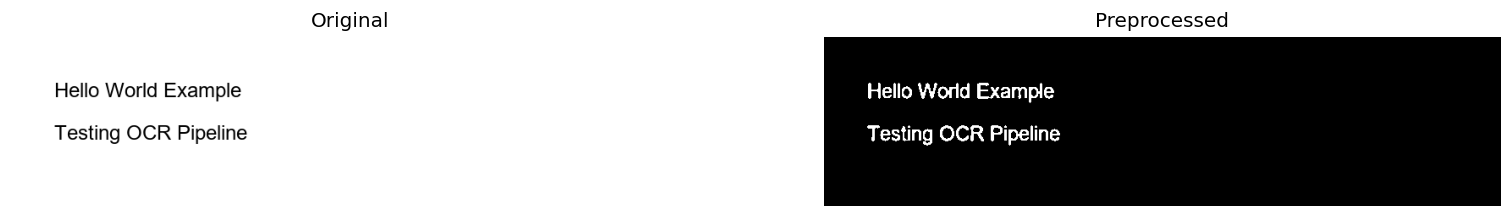

=== DEBUG PANEL ===
gray: shape=(200, 800), dtype=uint8
enhanced: shape=(200, 800), dtype=uint8
blurred: shape=(200, 800), dtype=uint8
denoised: shape=(200, 800), dtype=uint8
thresh: shape=(200, 800), dtype=uint8
cleaned: shape=(200, 800), dtype=uint8
deskew_angle: 0.0


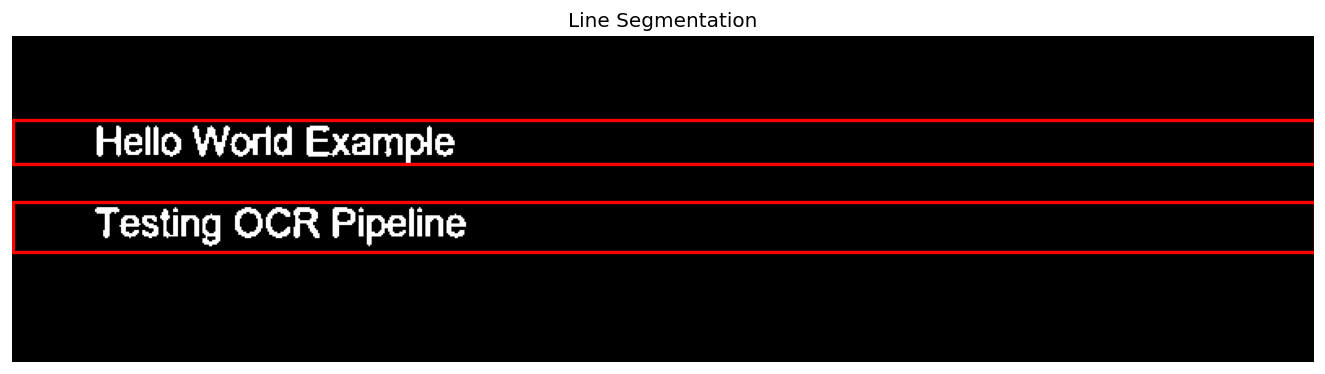

=== DEBUG PANEL ===
projection: shape=(200,), dtype=float32
threshold: 0.05999999865889549
line_count: 2
line_bboxes: 2 items


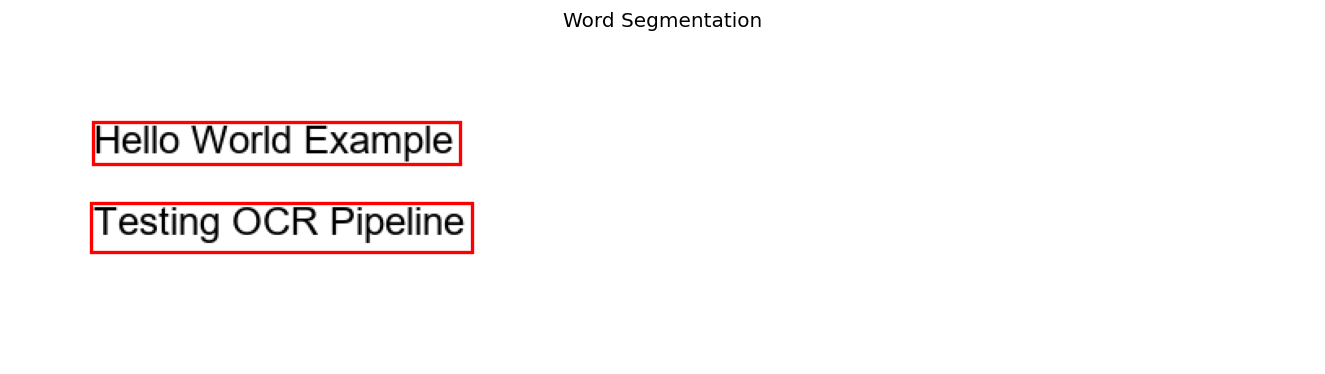

=== DEBUG PANEL ===
total_words: 2
Word Results:
 line_index  word_index                bbox language  language_confidence                                                                                                    text  ocr_confidence language_source
          0           0   (49, 52, 275, 78)  English                  0.5 [OCR_ERROR: tesseract is not installed or it's not in your PATH. See README file for more information.]             0.0       heuristic
          1           0 (48, 102, 282, 132)  English                  0.5 [OCR_ERROR: tesseract is not installed or it's not in your PATH. See README file for more information.]             0.0       heuristic
Reconstructed Text: [OCR_ERROR: tesseract is not installed or it's not in your PATH. See README file for more information.]
[OCR_ERROR: tesseract is not installed or it's not in your PATH. See README file for more information.]

PIPELINE COMPLETE
Detected 2 lines
Detected 2 words
Reconstructed text:
[OCR_ERROR: tesserac

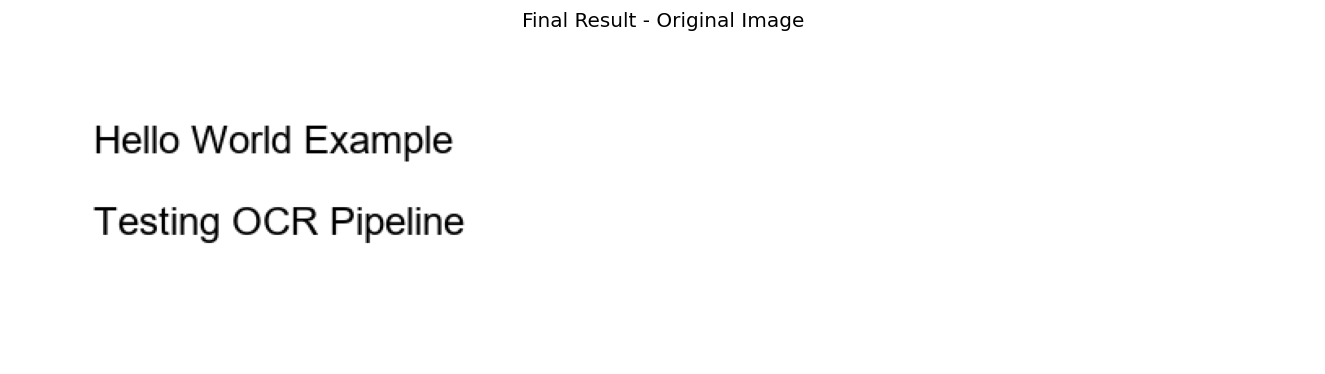

Word Results:
 line_index  word_index                bbox language  language_confidence                                                                                                    text  ocr_confidence language_source
          0           0   (49, 52, 275, 78)  English                  0.5 [OCR_ERROR: tesseract is not installed or it's not in your PATH. See README file for more information.]             0.0       heuristic
          1           0 (48, 102, 282, 132)  English                  0.5 [OCR_ERROR: tesseract is not installed or it's not in your PATH. See README file for more information.]             0.0       heuristic


In [9]:
def create_synthetic_image() -> np.ndarray:
    """Create a synthetic image with text for testing."""
    # Create blank image
    img = Image.new('RGB', (800, 200), color='white')
    draw = ImageDraw.Draw(img)
    
    # Try to use a font
    try:
        font = ImageFont.truetype("arial.ttf", 24)
    except:
        font = ImageFont.load_default()
    
    # Draw some text
    draw.text((50, 50), "Hello World Example", fill='black', font=font)
    draw.text((50, 100), "Testing OCR Pipeline", fill='black', font=font)
    
    # Convert to numpy array
    return np.array(img)


# Run demo
print("Creating synthetic test image...")
test_image = create_synthetic_image()

print("Running full pipeline...")
result = run_full_pipeline(test_image)

print("\n" + "="*50)
print("PIPELINE COMPLETE")
print("="*50)
print(f"Detected {len(result.lines)} lines")
print(f"Detected {len(result.words)} words")
print(f"Reconstructed text:\n{result.reconstructed_text}")
print("="*50)

# Show final results
show_image(test_image, "Final Result - Original Image")
show_word_results(result.words)

## Evaluation Section

Compute CER/WER metrics (placeholders for now).

In [10]:
def compute_cer(predicted: str, ground_truth: str) -> float:
    """Compute Character Error Rate."""
    if editdistance is not None:
        return editdistance.eval(predicted, ground_truth) / max(len(ground_truth), 1)
    else:
        return 0.0


def compute_wer(predicted: str, ground_truth: str) -> float:
    """Compute Word Error Rate."""
    if jiwer_wer is not None:
        return jiwer_wer(ground_truth, predicted)
    else:
        # Simple fallback
        pred_words = predicted.split()
        gt_words = ground_truth.split()
        if not gt_words:
            return 0.0
        return editdistance.eval(pred_words, gt_words) / len(gt_words) if editdistance else 0.0


def evaluate_pipeline(result: PipelineResult, ground_truth: str) -> Dict[str, float]:
    """Evaluate the pipeline results against ground truth."""
    predicted = result.reconstructed_text
    
    return {
        'cer': compute_cer(predicted, ground_truth),
        'wer': compute_wer(predicted, ground_truth),
        'char_accuracy': 1.0 - compute_cer(predicted, ground_truth),
        'word_accuracy': 1.0 - compute_wer(predicted, ground_truth)
    }


# Demo evaluation
ground_truth = "Hello World Example\nTesting OCR Pipeline"
metrics = evaluate_pipeline(result, ground_truth)

print("Evaluation Metrics:")
for key, value in metrics.items():
    print(f"  {key}: {value:.4f}")

print("[OK] Evaluation functions loaded")

Evaluation Metrics:
  cer: 4.5750
  wer: 6.6000
  char_accuracy: -3.5750
  word_accuracy: -5.6000
[OK] Evaluation functions loaded


## Summary

This notebook implements a debug-first, modular OCR pipeline with:

- **Preprocessing**: CLAHE, denoising, thresholding, deskewing
- **Line Segmentation**: Horizontal projection analysis
- **Word Segmentation**: Contour detection with gap merging
- **Language Detection**: OCR-based script identification
- **OCR**: Language-specific Tesseract recognition
- **Post-processing**: Text reconstruction from word results

Key features:
- Every stage stores debug artifacts
- Visual inspection at every step
- Modular design for easy extension
- Fallback mechanisms for robustness
- Structured data classes for results

To use with real data, set `IMAGE_PATH` and call `run_full_pipeline()`.